## 初级要求

数据集形状: (178, 13)
真实聚类数: 3
特征名: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


d:\Machine_Learning\lab5\hierarchical_clustering.py:206: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Machine_Learning\lab5\hierarchical_clustering.py:206: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Machine_Learning\lab5\hierarchical_clustering.py:206: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Machine_Learning\lab5\hierarchical_clustering.py:206: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Machine_Learning\lab5\hierarchical_clustering.py:206: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Machine_Learning\lab5\hierarchical_clustering.py:206: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) DejaVu Sans.
 

✓ 基本对比图已保存: clustering_comparison_basic.png


d:\miniconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26641 (\N{CJK UNIFIED IDEOGRAPH-6811}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\minicon

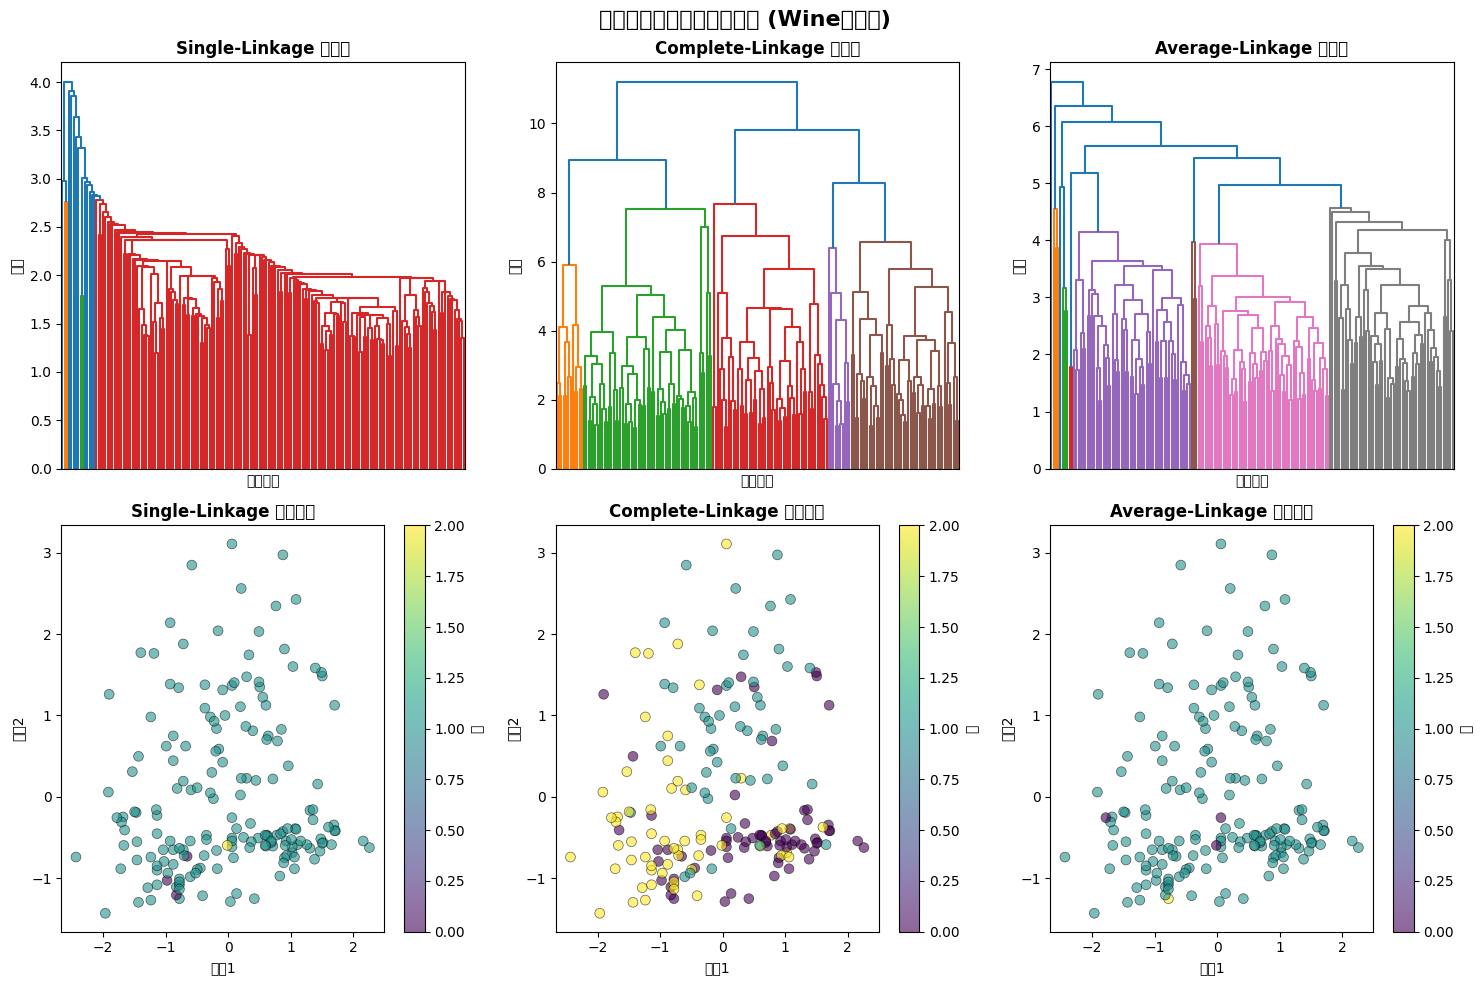


方法                   - 聚类质量评估 (Silhouette Score)
--------------------------------------------------
Single               - Silhouette Score: 0.1827
Complete             - Silhouette Score: 0.2038
Average              - Silhouette Score: 0.1575


In [1]:
# 从同目录下的 Python 文件中导入函数和类
from hierarchical_clustering import (
    HierarchicalClustering,
    load_and_prepare_wine_data,
    plot_comparison,
    evaluate_clustering,
)
import numpy as np

# 1. 加载并预处理 wine 数据集
X, y_true, feature_names = load_and_prepare_wine_data()
print("数据集形状:", X.shape)
print("真实聚类数:", len(np.unique(y_true)))
print("特征名:", feature_names)

# 2. 使用三种链接方式进行聚类并画图
n_clusters = 3
clusterings, labels_dict = plot_comparison(X, y_true, n_clusters=n_clusters)

# 3. 简单评估三种方法的聚类效果（Silhouette Score）
print(f"\n{'方法':<20} - 聚类质量评估 (Silhouette Score)")
print("-" * 50)
for method in ['single', 'complete', 'average']:
    evaluate_clustering(X, labels_dict[method], method.capitalize())

In [4]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import time
# 1. 加载数据
X, y_true, feature_names = load_and_prepare_wine_data()
n_clusters = 3

linkage_method = 'single'  # 'single' / 'complete' / 'average'

# 2. 你的手搓实现
hc = HierarchicalClustering(method=linkage_method)

t0 = time.time()
hc.fit(X)
labels_manual = hc.predict(n_clusters=n_clusters)
time_manual = time.time() - t0

sil_manual = silhouette_score(X, labels_manual)
print(f"[手搓 {linkage_method}]  时间: {time_manual*1000:.2f} ms, Silhouette: {sil_manual:.4f}")

# 3. sklearn 的层次聚类实现
# 注意：AgglomerativeClustering 的 linkage 参数和你的 method 对应
sk_model = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='euclidean',   # sklearn < 1.4 用 affinity，新版用 metric
    linkage=linkage_method  # 'ward' / 'complete' / 'average' / 'single'
)

t0 = time.time()
labels_sklearn = sk_model.fit_predict(X)
time_sklearn = time.time() - t0

sil_sklearn = silhouette_score(X, labels_sklearn)
print(f"[sklearn {linkage_method}] 时间: {time_sklearn*1000:.2f} ms, Silhouette: {sil_sklearn:.4f}")

[手搓 single]  时间: 1514.00 ms, Silhouette: 0.1827
[sklearn single] 时间: 4.02 ms, Silhouette: 0.1827


In [5]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import time
# 1. 加载数据
X, y_true, feature_names = load_and_prepare_wine_data()
n_clusters = 3

linkage_method = 'complete'  # 'single' / 'complete' / 'average'

# 2. 你的手搓实现
hc = HierarchicalClustering(method=linkage_method)

t0 = time.time()
hc.fit(X)
labels_manual = hc.predict(n_clusters=n_clusters)
time_manual = time.time() - t0

sil_manual = silhouette_score(X, labels_manual)
print(f"[手搓 {linkage_method}]  时间: {time_manual*1000:.2f} ms, Silhouette: {sil_manual:.4f}")

# 3. sklearn 的层次聚类实现
# 注意：AgglomerativeClustering 的 linkage 参数和你的 method 对应
sk_model = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='euclidean',   # sklearn < 1.4 用 affinity，新版用 metric
    linkage=linkage_method  # 'ward' / 'complete' / 'average' / 'single'
)

t0 = time.time()
labels_sklearn = sk_model.fit_predict(X)
time_sklearn = time.time() - t0

sil_sklearn = silhouette_score(X, labels_sklearn)
print(f"[sklearn {linkage_method}] 时间: {time_sklearn*1000:.2f} ms, Silhouette: {sil_sklearn:.4f}")

[手搓 complete]  时间: 830.31 ms, Silhouette: 0.2038
[sklearn complete] 时间: 1.00 ms, Silhouette: 0.2038


In [6]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import time
# 1. 加载数据
X, y_true, feature_names = load_and_prepare_wine_data()
n_clusters = 3

linkage_method = 'average'  # 'single' / 'complete' / 'average'

# 2. 你的手搓实现
hc = HierarchicalClustering(method=linkage_method)

t0 = time.time()
hc.fit(X)
labels_manual = hc.predict(n_clusters=n_clusters)
time_manual = time.time() - t0

sil_manual = silhouette_score(X, labels_manual)
print(f"[手搓 {linkage_method}]  时间: {time_manual*1000:.2f} ms, Silhouette: {sil_manual:.4f}")

# 3. sklearn 的层次聚类实现
# 注意：AgglomerativeClustering 的 linkage 参数和你的 method 对应
sk_model = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='euclidean',   # sklearn < 1.4 用 affinity，新版用 metric
    linkage=linkage_method  # 'ward' / 'complete' / 'average' / 'single'
)

t0 = time.time()
labels_sklearn = sk_model.fit_predict(X)
time_sklearn = time.time() - t0

sil_sklearn = silhouette_score(X, labels_sklearn)
print(f"[sklearn {linkage_method}] 时间: {time_sklearn*1000:.2f} ms, Silhouette: {sil_sklearn:.4f}")

[手搓 average]  时间: 846.39 ms, Silhouette: 0.1575
[sklearn average] 时间: 1.01 ms, Silhouette: 0.1575
